In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [17]:
country_list = pd.read_csv("C:\\heroku\\median-tariff\\data\\country-list-20.csv", header=None, names=["CTY_CODE"])

file = f"C:\\heroku\\how-restrictive-us-trade\\data\\hs6-enduse.parquet"

dfenduse = pd.read_parquet(file)

dfenduse["ENDUSE"] = dfenduse["BEC5EndUse"]

dfenduse["HS6"] = dfenduse["HS6"].astype(str)

In [18]:
file = f"C:\\heroku\\how-restrictive-us-trade\\data\\imports-hs10\\TOTALdata-current.parquet"

# Load country data
df = pq.read_table(file).to_pandas()

df["CAL_DUT_MO"] = df["CAL_DUT_MO"].astype(float)

df["CON_VAL_MO"] = df["CON_VAL_MO"].astype(float)

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["HS2"] = df["I_COMMODITY"].astype(str).str[:2]

# Create HS code hierarchy columns
df["HS6"] = df["I_COMMODITY"].str[0:6]
df["HS4"] = df["I_COMMODITY"].str[0:4]
df["HS8"] = df["I_COMMODITY"].str[0:8]
df["HS10"] = df["I_COMMODITY"]


In [19]:
df.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,I_COMMODITY,I_COMMODITY_SDESC,time,COMM_LVL,HS2,HS6,HS4,HS8,HS10
0,TOTAL FOR ALL COUNTRIES,773010.0,0.0,0602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,06,060240,0602,06024000,0602400000
1,TOTAL FOR ALL COUNTRIES,6177543.0,0.0,0602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,06,060290,0602,06029020,0602902000
2,TOTAL FOR ALL COUNTRIES,135786.0,0.0,0602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,06,060290,0602,06029030,0602903010
3,TOTAL FOR ALL COUNTRIES,169439.0,0.0,0602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,06,060290,0602,06029030,0602903090
4,TOTAL FOR ALL COUNTRIES,2177498.0,25345.0,0602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,06,060290,0602,06029040,0602904000


In [42]:
excluded_hs2 = ["27", "30", "71", "88", "98", "99"]

dfsec = df[~df["HS2"].isin(excluded_hs2)]

dfsec = dfsec[dfsec["HS6"].isin(dfenduse[dfenduse["ENDUSE"] == "INT"]["HS6"].unique())]

grp = dfsec.groupby(["HS4"])

bar = grp["CON_VAL_MO"].sum().reset_index()

bar["share"] = bar["CON_VAL_MO"] / bar["CON_VAL_MO"].sum()

# bar = bar[~bar["HS2"].isin(["99", "98", "27", "71"])]

top_products = bar.sort_values(by="CON_VAL_MO", ascending=False).iloc[:10]
        
top_products.reset_index(inplace = True, drop= True)

top_20products = bar.sort_values(by="CON_VAL_MO", ascending=False).iloc[:10]
        
print(top_20products)

      HS4    CON_VAL_MO     share
794  8708  8.507317e+11  0.081412
784  8542  4.325909e+11  0.041398
743  8473  3.607638e+11  0.034524
712  8411  3.224889e+11  0.030861
785  8544  2.968618e+11  0.028409
750  8481  1.963825e+11  0.018793
357  4011  1.910493e+11  0.018283
779  8537  1.666775e+11  0.015951
758  8507  1.550186e+11  0.014835
778  8536  1.476573e+11  0.014130


In [40]:
top_20products.share.sum()

0.45631690660828067

In [23]:
def make_tariff_country_date(dfcntry, date):
   
   bar = dfcntry[(dfcntry['time'] == date)].copy()

   bar["tariff"] = bar["CAL_DUT_MO"] / bar["CON_VAL_MO"]

   bar = bar[["I_COMMODITY", "CON_VAL_MO", "CAL_DUT_MO", "tariff", "CTY_NAME"]]

   return bar

In [24]:
def make_good_country_year(dfcntry, year):
    """
    Process country data for a specific year and calculate aggregate metrics.
    
    Parameters:
    -----------
    dfcntry : pandas.DataFrame
        DataFrame containing country trade data with columns:
        - time: datetime
        - I_COMMODITY: commodity code
        - CON_VAL_MO: consumption value
        - CAL_DUT_MO: calculated duty
        - CTY_NAME: country name
    year : str
        Year to filter data (e.g., "2024")
    
    Returns:
    --------
    pandas.DataFrame
        Aggregated data by commodity for the specified year
    """
    # Filter to specific year
    df_year = dfcntry[dfcntry['time']== year]
    
    # Group by commodity and aggregate
    grp = df_year.groupby("I_COMMODITY")
    
    result = grp.agg({
        "CON_VAL_MO": "sum",
        "CAL_DUT_MO": "sum",
        "CTY_NAME": "first"})
    
    
    return result

In [25]:
def process_sectors_for_date(country_list, enduse, target_date, weight_year="2024", selected_country=None):
    """
    Process multiple countries and create combined dataset with weights.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    enduse : str
        ENDUSE category to filter data (e.g., "INT", "CAP", "CON")
    target_date : str
        Date to extract tariff data for (e.g., "2025-08")
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    selected_country : str, optional
        Country name to filter results (e.g., "CANADA"). If None, returns all countries (default: None)
    
    Returns:
    --------
    pandas.DataFrame
        Combined dataframe with tariff data and weights for all countries (or selected country)
    """
    # Handle both DataFrame and list inputs
    if isinstance(country_list, pd.DataFrame):
        countries = country_list.CTY_CODE
    else:
        countries = country_list
    
    all_results = []
    tariff_results = []
    
    for country in countries:
        
        file = f"C:\\heroku\\how-restrictive-us-trade\\data\\imports-hs10\\{country}data-current.parquet"
        
        # Load country data
        dfcntry = pq.read_table(file).to_pandas()
        
        dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

        dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

        dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

        dfcntry["HS6"] = dfcntry["I_COMMODITY"].str[0:6]
        
        dfcntry = pd.merge(dfcntry, dfenduse[["HS6", "ENDUSE"]], on="HS6", how="left")

        dfcntry_sector = dfcntry[dfcntry["ENDUSE"] == enduse].copy()
            
        # Calculate metrics for weight year
        results_df = make_good_country_year(dfcntry_sector, weight_year)

        results_df.reset_index(inplace=True)
        
        # Get tariff data for target date
        tariff_df = make_tariff_country_date(dfcntry_sector, target_date)

        tariff_df.reset_index(drop=True, inplace=True)
        
        # Add to lists
        all_results.append(results_df)

        tariff_results.append(tariff_df)
        
        #print(f"Processed {country}: {results_df['CTY_NAME'].iloc[0]}")
    
    # Combine all results into one dataframe
    combined_results = pd.concat(all_results)
    combined_results.reset_index(drop=True, inplace=True)
    
    combined_tariff_results = pd.concat(tariff_results)
    combined_tariff_results.reset_index(drop=True, inplace=True)
    
    # Calculate weights
    combined_results["weights"] = combined_results["CON_VAL_MO"] / combined_results["CON_VAL_MO"].sum()
    
    # Merge weights with tariff data
    bigdf = pd.merge(
        combined_results[["I_COMMODITY", "CTY_NAME", "weights"]], 
        combined_tariff_results, 
        how="left", 
        on=["I_COMMODITY", "CTY_NAME"]
    )
    
    # Filter to selected country if specified
    if selected_country is not None:
        bigdf = bigdf[bigdf["CTY_NAME"] == selected_country].copy()
        # Renormalize weights to sum to 1 for the selected country
        bigdf["weights"] = bigdf["weights"] / bigdf["weights"].sum()

    
        return bigdf
    return bigdf

In [26]:
def create_tariff_metrics_by_date_sector(enduse_list, date_list, weight_year="2024"):
    """
    Calculate tariff metrics for multiple dates and countries.
    
    Parameters:
    -----------
    enduse_list : list
        List of ENDUSE categories to process (e.g., ["INT", "CAP", "CON"])
    date_list : list
        List of date strings to process (e.g., ["2024-08", "2025-02", "2025-08"])
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: date, ENDUSE, sqrtariff, meanweighted, simplemean
    """
    results = []
    
    for date in date_list:

        for enduse in enduse_list:
            
            print(f"Processing date: {date}, ENDUSE: {enduse}")
        
            # Get data for this date (all countries)
            bigdf = process_sectors_for_date(country_list, enduse, date, weight_year=weight_year)
        
            # Calculate metrics for ALL COUNTRIES combined
            sqrtariff_all = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5
            meanweighted_all = (bigdf["tariff"] * bigdf["weights"]).sum()
            simplemean_all = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()
        
            # Store ALL COUNTRIES results
            results.append({
                'date': date,
                'ENDUSE': enduse,
                'sqrtariff': sqrtariff_all,
                'meanweighted': meanweighted_all,
                'simplemean': simplemean_all
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

In [29]:
target_date = "2025-10"

bigdf = process_sectors_for_date(country_list, "INT", target_date, weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted TRI Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

# Format the date

# formatted_date = pd.to_datetime(target_date, format="%Y-%m").strftime("%B %Y")

# with open(texfile, 'w') as f:
#     f.write(f'\\newcommand{{\\rmsValuetwofive}}{{{sqrtariff*100:.0f}}}\n')
#     f.write(f'\\newcommand{{\\meanWeightedValuetwofive}}{{{meanweighted*100:.0f}}}\n')
#     f.write(f'\\newcommand{{\\simpleMeanValuetwofive}}{{{simplemean*100:.0f}}}\n')
#     f.write(f'\\newcommand{{\\currentdate}}{{{formatted_date}}}\n')
#     f.write(f'\\newcommand{{\\diffmeanWeightedValuetwofive}}{{{(sqrtariff*100 - meanweighted*100):.0f}}}\n')
#     f.write(f'\\newcommand{{\\diffsimpleMeanValuetwofive}}{{{(sqrtariff*100 - simplemean*100):.0f}}}\n')


Weighted TRI Tariff: 24.37%
 
Weighted Mean Tariff: 13.89%
 
Simple Mean Tariff: 11.63%


In [30]:
date_list = ["2025-01", "2025-02", "2025-03", "2025-04", "2025-05", "2025-06", "2025-07", "2025-08", "2025-09", "2025-10"]

enduse_list = ["CONS", "CAP", "INT"]

metrics_df = create_tariff_metrics_by_date_sector(enduse_list, date_list, weight_year="2024")

metrics_df["date"] = pd.to_datetime(metrics_df["date"], format="%Y-%m")

metrics_df.to_parquet("C:\\heroku\\how-restrictive-us-trade\\data\\enduse-metrics.parquet", index=False)

Processing date: 2025-01, ENDUSE: CONS
Processing date: 2025-01, ENDUSE: CAP
Processing date: 2025-01, ENDUSE: INT
Processing date: 2025-02, ENDUSE: CONS
Processing date: 2025-02, ENDUSE: CAP
Processing date: 2025-02, ENDUSE: INT
Processing date: 2025-03, ENDUSE: CONS
Processing date: 2025-03, ENDUSE: CAP
Processing date: 2025-03, ENDUSE: INT
Processing date: 2025-04, ENDUSE: CONS
Processing date: 2025-04, ENDUSE: CAP
Processing date: 2025-04, ENDUSE: INT
Processing date: 2025-05, ENDUSE: CONS
Processing date: 2025-05, ENDUSE: CAP
Processing date: 2025-05, ENDUSE: INT
Processing date: 2025-06, ENDUSE: CONS
Processing date: 2025-06, ENDUSE: CAP
Processing date: 2025-06, ENDUSE: INT
Processing date: 2025-07, ENDUSE: CONS
Processing date: 2025-07, ENDUSE: CAP
Processing date: 2025-07, ENDUSE: INT
Processing date: 2025-08, ENDUSE: CONS
Processing date: 2025-08, ENDUSE: CAP
Processing date: 2025-08, ENDUSE: INT
Processing date: 2025-09, ENDUSE: CONS
Processing date: 2025-09, ENDUSE: CAP
Pro

In [ ]:


#metrics_df = pd.read_parquet("C:\\heroku\\how-restrictive-us-trade\\data\\top-sector-metrics.parquet")


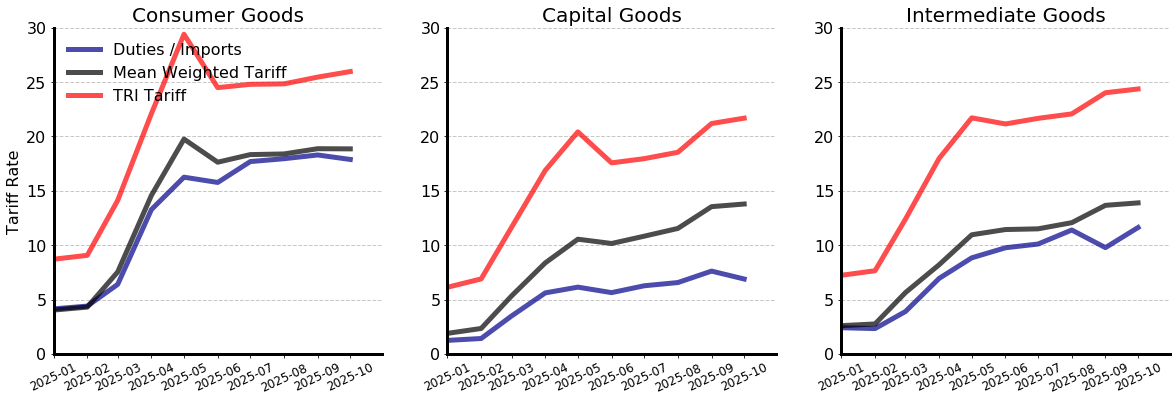

In [44]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, figsize = (20,6)) 

enduse_categories = ["CONS", "CAP", "INT"]

titles = ["Consumer Goods", "Capital Goods", "Intermediate Goods"]

ax = ax.ravel() # Flatten to work through in a loop
    
for i, (ax_subplot, enduse) in enumerate(zip(ax, enduse_categories)):

    foo = metrics_df[metrics_df["ENDUSE"] == enduse].copy()

    ax_subplot.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Duties / Imports")

    ax_subplot.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Weighted Tariff")

    ax_subplot.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

    ax_subplot.set_title(titles[i], fontsize = 20)

    ax_subplot.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,10,30)])

    ax_subplot.set_ylim(bottom=0)

    ax_subplot.tick_params(axis='x', labelsize=12, rotation=25)
    ax_subplot.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

    ax_subplot.set_ylim(0,30)

    ax_subplot.spines["right"].set_visible(False)

    ax_subplot.spines["top"].set_visible(False)

    ax_subplot.spines["left"].set_linewidth(3)

    ax_subplot.spines["bottom"].set_linewidth(3)

    ax_subplot.grid(axis='y', linewidth=1, linestyle='--', alpha=0.7)

    if i == 0:  # Only show legend in first plot
        ax_subplot.legend(
            fontsize=16,           # Font size
            frameon=False,         # No box
            loc='upper left',     # Position
            ncol=1                 # Number of columns
        )

        ax_subplot.set_ylabel("Tariff Rate", fontsize=16)


# plt.savefig(figfile+"panel-enduse-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"panel-enduse-tariffs.pdf", bbox_inches = "tight")

plt.show()